# **4.** Learning: How to train an AI algorithm?

Now that we know how to work with datasets, and we have identified useful features for each problem we're going to tackle, we can start with the interesting part: How do we train a machine to make a decisions?

We will explore a machine learning paradigm called **supervised learning**. Supervised learning is a type of machine learning where the computer learns from data that **includes the "right answers"** - in other words, each example comes with a label that tells the model what the correct output should be. The goal is for the model to learn the relationship between the input data and these labels, so it can make **accurate predictions on new, unseen data.**

For example:
- Predicting tomorrow's temperature based on past weather data
- Classifying news articles by topic (e.g. politics, sports, entertainment)
- Detecting fraudulent transactions by learning from examples of both normal and fraudulent activity

<img src="https://images.prismic.io/superpupertest/f3517801-371b-4be8-95f0-f18b3b7804f2_How-does-supervised-learning-work.webp?auto=compress,format&dpr=3" width="600px"/>

In our case, we're going to use supervised learning to train a model for each of the tasks we discussed in the previous notebook:
* Classifying movie reviews into positive or negative
* Classifying instruments into musical families
* Classifying images into object categories

## Nearest Neighbour

Imagine we are analysing data that corresponds to two different classes: class A and class B. And let's say we have the value of two features, feature_1 and feature_2, for every data sample.

The data might look something like this:

In [4]:
toy_data_string = """feature_1,feature_2,class
0.1,0.2,A
0.2,0.1,A
0.8,0.9,B
0.9,0.8,B
0.5,0.5,A
0.6,0.6,B
0.3,0.4,A
0.4,0.3,A
0.7,0.8,B"""

In this case we can see a nice 2D plot showing where each sample is in the plane formed by the two features.

<Axes: xlabel='feature_1', ylabel='feature_2'>

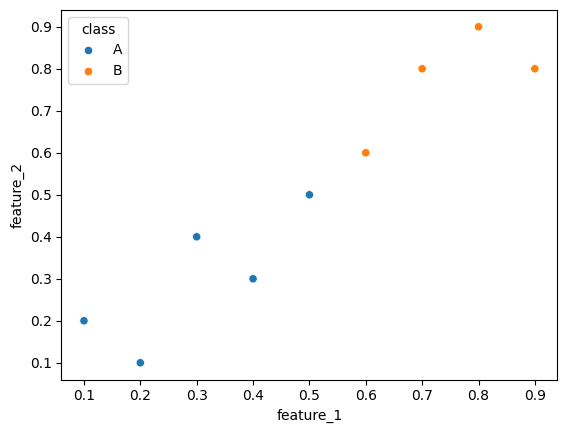

In [7]:
from io import StringIO
import pandas as pd
import seaborn as sns

X_train = pd.read_csv(StringIO(toy_data_string))
sns.scatterplot(data=X_train, x="feature_1", y="feature_2", hue="class")

Now, imagine we have a new data point, and we don't know its class yet:

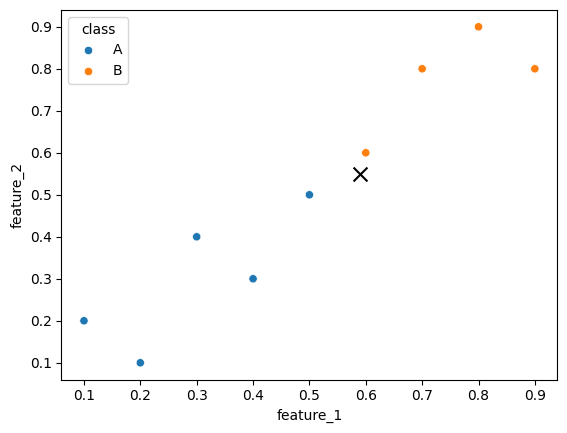

In [8]:
import matplotlib.pyplot as plt
import numpy as np

x_test = np.array([0.59, 0.55], dtype=float)
sns.scatterplot(data=X_train, x="feature_1", y="feature_2", hue="class")
plt.scatter(x_test[0], x_test[1], c='black', marker='x', s=100)

> Looking at the plot, what class would you assign to it and why?

In this example, you would probably look at which sample of data is closest to the one we are trying to classify, and use the same label they have! In this case, it looks like it's closer to a point with class B.

This is exactly the reasoning behind the **Nearest Neighbour** algorithm. This algorithm remembers all the features and classes of the data it was trained with. For a previously unseen data sample, it checks which is the training sample that's closest, and then, it assigns the class of its nearest neighbor to the new sample.


We can define it formally as it follows:

Given a test point $x_{test}^*$ and a dataset of points $x_{train} = \{x_{train_1}, x_{train_2}, \ldots, x_{train_n}\}$, 
the Nearest Neighbor algorithm finds the point $x_{train}^*$ that minimizes a distance function $d$:

$$x_{train}^* = \arg\min_{{x_{train_i} \in x_{train}}} \, d(x_{test}^*, x_{train_i})$$

where the distance between two points is defined in this case as:

$$d(x_{test}^*, x_{train_i}) = \sqrt{(\text{feature}_1(x_{test}^*) - \text{feature}_1(x_{train_i}))^2 + (\text{feature}_2(x_{test}^*) - \text{feature}_2(x_{train_i}))^2}$$

The algorithm then assigns the class of $x_{train}^*$ to the test point $x_{test}^*$.

If we have N features, we can modify the distance function to:

$$d(x_{\text{test}^*}, x_{\text{train}_i}) = \sqrt{\sum_{j=1}^{N}(\text{feature}_j(x_{\text{test}}^*) - \text{feature}_j(x_{\text{train}_i}))^2}$$


What would this look like for our data? First, we need to compute the distances to all the points we trained the classifier with.

In [9]:
import numpy as np

diff = x_test - X_train.values[:, :2].astype(float)
distances = np.sqrt(np.sum(np.square(diff), axis=1))

Then, we need to check which is the data sample that's the closest to the new sample we want to classify. In other words, which sample of data minimises the distance function.

In [10]:
X_train.iloc[np.argmin(distances)]

feature_1    0.6
feature_2    0.6
class          B
Name: 5, dtype: object

Then, we can say that our new test sample should be classified as belonging to class B!

## k-Nearest Neighbours

A way extending the previous idea to get a more robust classifier is to use a **k-Nearest Neighbours** algorithm.

The idea is very similar. Mathematically, k-NN uses the feature vector assigned to each data point. When predicting this point's label, it computes the **distance** between this point and all points in the training set. Then, it selects the $k$ closest points from the training data (hence, k-nearest neighbours!). The predicted label is typically the majority label among these neighbours.

We will need to choose the value of $k$ (how many neighbours we're searching for) that gives us the best result as we fit our model!

## Data Splitting ➗

### Training and test sets

Before we can start with supervised learning, we need to **split our data**. Why do we do this? Imagine we train our model with all our data, and spend a lot of effort trying to make it perform well for it. The problem is will still have no idea of how the model reacts to data it has never seen. It might as well be getting super good at memorising only those particular cases!

How best to split a dataset depends on many qualities, including how it was made and the number of data points within it. For now, we're just going to split our dataset into two separate parts:
- The **training set** consists of the data points we'll use to train the model;
- The **test set** consists of the data points we'll use to evaluate how well it performs. You may also see the test set called the **held-out data**, as it is **held out** from the model and not seen during training.

We need both splits of the dataset to truly understand our model: without the training split, we can't learn anything, and without the test split, we can't evaluate what we've learned.


Let's use our audio data to exemplify how this would be done in Python. Let's load the data `csv` into a `Dataframe` and see what the first rows of data have stored.

In [11]:
import pandas as pd

tinysol_dataset = pd.read_csv("features_and_labels_audio.csv")
tinysol_dataset.head()

,Spectral Centroid,Spectral Bandwidth,RMS,Zero-Crossing Rate,Family
0,5633.172265,3118.915778,1.649794,0.008589,Brass
1,5643.018662,3119.580742,1.627017,0.008592,Brass
2,5685.157258,3094.128050,1.610967,0.011369,Brass
3,5646.330359,3118.488256,1.627235,0.019568,Brass
4,5689.932701,3087.401249,1.633211,0.012646,Brass


Good! So each row is an audio file, and we have four feature values and a "Family" class.

We can use `sklearn` to split our data into training and test sets. The standard notation is generally using `X` for the observation data, and `y` for the labels (since it's the output we want). Once we perform the split we end up with two `X` and two `y` variables, corresponding to the training and test data, respectively. In this case, we choose to keep 80% of the data for training, and 20% for testing.

In [12]:
from sklearn.model_selection import train_test_split

X = tinysol_dataset.drop(columns=["Family"])
y = tinysol_dataset["Family"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    test_size=0.2,
    random_state=0
)
print(f"Training feature size: {X_train.shape}")
print(f"Training label size: {y_train.shape}")
print(f"Test feature size: {X_test.shape}")
print(f"Test label size: {y_test.shape}")

Training feature size: (2330, 4)
Training label size: (2330,)
Test feature size: (583, 4)
Test label size: (583,)


Let's take a look at the number of recordings for each family in our splits. We'll express this as a proportion of the total number of recordings in both splits.

In [13]:
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

family_percentages = pd.DataFrame({
    "train_pct": (train_counts / len(y_train) * 100),
    "test_pct": (test_counts / len(y_test) * 100)
}).fillna(0).round(2)

print(family_percentages)

           train_pct  test_pct
Family                        
Brass          15.88     14.58
Keyboards      22.49     28.30
Strings        41.85     37.39
Winds          19.79     19.73


### Stratified Splitting ➗

That's interesting: 28% of the recordings in our test data feature **Keyboards**, but only 22% of those in the training data feature this family. If our dataset was **very unbalanced**, this could be a problem.

> For example, imagine we were building a model to predict whether a patient has a certain disease, but **95%** of the training data are healthy patients and only **5%** have the disease. Without careful handling, the model might just predict “healthy” for everyone, since it sees **so few examples of the disease.**

To accomodate this, we may want to **stratify** our data splits. This will keep the number of recordings per class approximately equal across both splits:

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [10]:
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

family_percentages = pd.DataFrame({
    "train_pct": (train_counts / len(y_train) * 100),
    "test_pct": (test_counts / len(y_test) * 100)
}).fillna(0).round(2)

print(family_percentages)

           train_pct  test_pct
Family                        
Brass          15.62     15.61
Keyboards      23.65     23.67
Strings        40.94     40.99
Winds          19.79     19.73


Much better: after stratification, we can see that the proportion of recordings by each family is **roughly the same** across both training and test data splits.

#### Data Leakage 🚰

One of the most common mistakes made by students when training machine learning models is **data leakage**. This is when data used to train the model is accidentally used to evaluate it, as well.

> Imagine if you were studying for a maths exam, and somehow the exam questions were included in your study guide. You might score perfectly, but it wouldn't reflect your true understanding of maths - you just memorised the answers in advance.

Data leakage works the same way in machine learning. Luckily, `sklearn` handles data splitting in such a way that prevents leakage. However, we can check our dataset to ensure that no feature vector in the training set also appears in the test set:

In [11]:
# Convert each row to a tuple so we can easily compare them
train_rows = [tuple(row) for row in X_train.values]
test_rows = [tuple(row) for row in X_test.values]

# Check if any training row appears in the test data
for train_row in train_rows:
    if train_row in test_rows:
        print("WARNING: Found the same data in both training and test sets!")
        break
else:
    print("✓ No data leakage detected - training and test sets are separate")

✓ No data leakage detected - training and test sets are separate


The `for` loop written above will test each row of the training data to make sure that it doesn't appear in the test data.

### Alternative Data Splitting Methods ➗

Splitting into separate training and test data is perhaps the simplest way of splitting a dataset. There are many alternatives, including:

- $k$-fold **cross validation**: rather than obtaining only one training and test dataset, we obtain $k$ training and test datasets. We typically set the value of $k$ such that each item in the dataset appears in at least one test split. To get the final performance of our model, we train on every training dataset and predict the corresponding test data, then average the performance over $k$. This means that, if our model performs very well (or very badly) on one test dataset, this won't effect the results overall.
- **train-validation-test**: this involves splitting our held-out data again into two separate splits, called the **validation** and **test** data. During training, we periodically check our performance on the validation data: once we've finished training, we evaluate the model for the final time on the test data. This is especially common when training **deep learning** models, where we may want to use the performance on the **validation** data to tell us when to stop training.

## Data preparation

Let's visualise our train data, plotting pairplots of the four features we have.

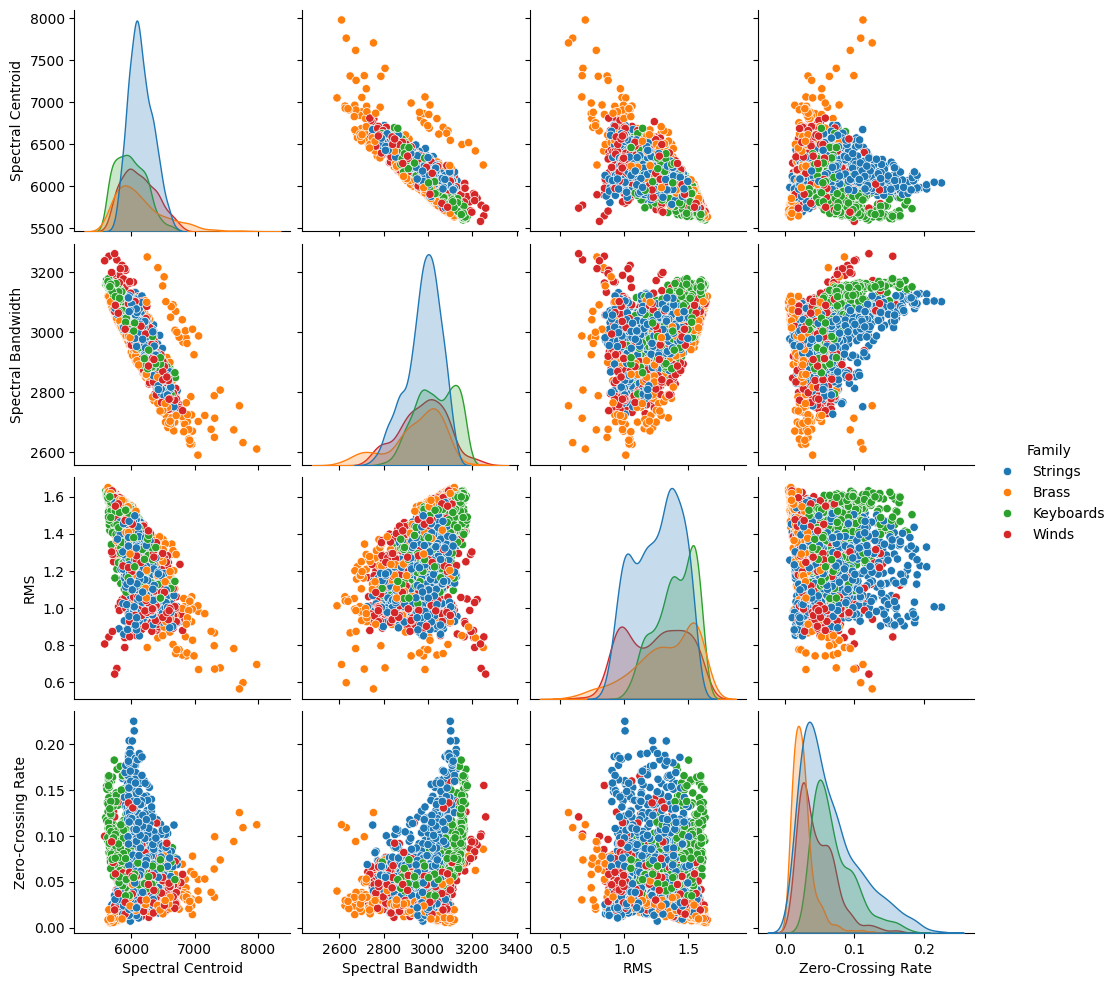

In [16]:
train_data = X_train.copy()
train_data['Family'] = y_train
sns.pairplot(train_data, hue='Family')

> Looking at the plots, do you have any observations? Are there features that are more useful for separating between families? Are certain families easier to separate from the others?

One problem we are going to have, is that all features are varying in different ranges! If we are going to be measuring distances, this will have a huge impact. In order to treat each feature with equal importance, we need to **normalise** their values.

### Normalisation 🔢

Normalisation means to adjust values measured on diferent scales to a *common scale*. We'll use one of the possible approaches for normalisation.

*Min-max normalisation*: this involves rescaling the values for a feature to between 0 and 1. We assign 0 to the smallest value, and 1 to the largest. To transform the feature $x$ to the normalised feature $\hat{x}$:

$$
\hat{x} = \dfrac{x - \text{min}(x)}{\text{max}(x) - \text{min}(x)}
$$

In [17]:
X_train_normalised = (X_train - X_train.min()) / (X_train.max() - X_train.min())

Let's look at the data now:

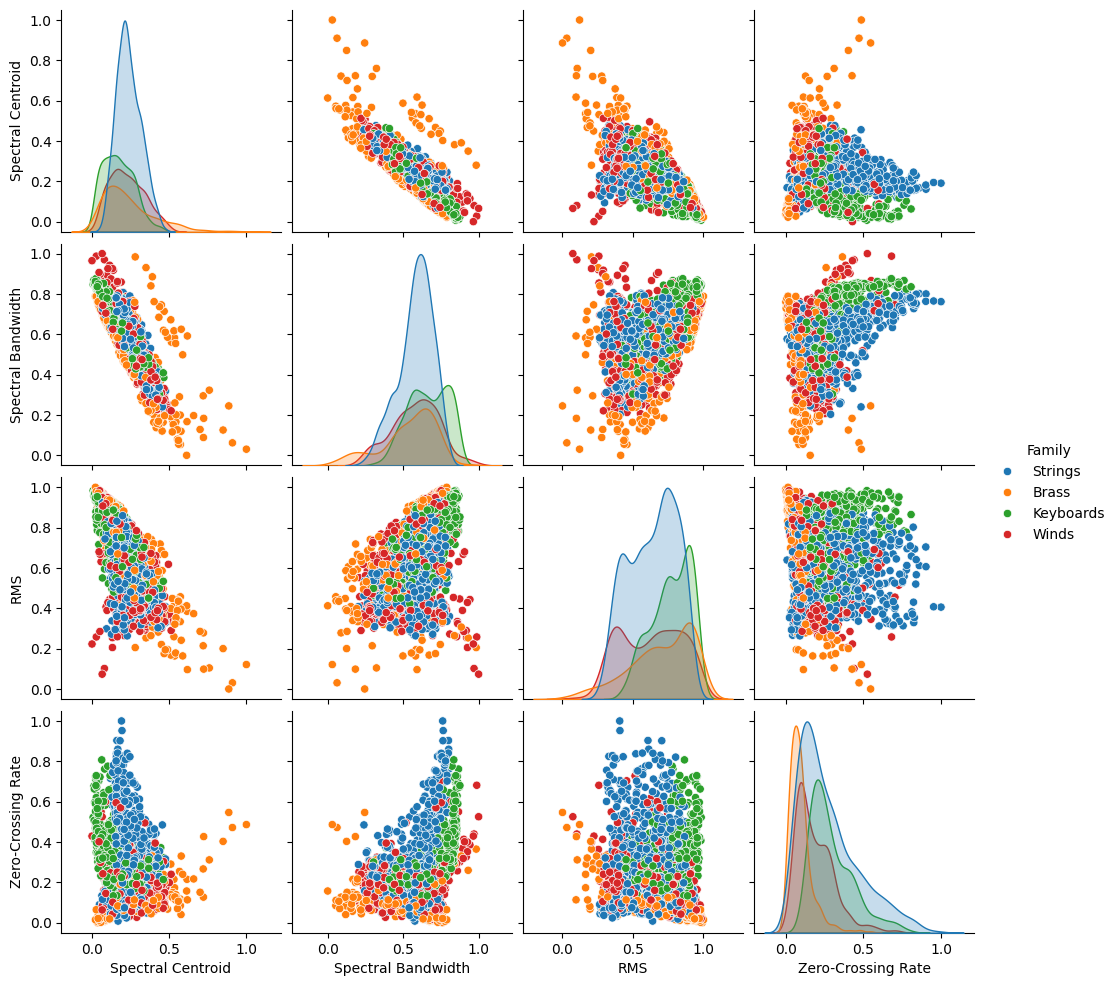

In [18]:
train_data_normalised = X_train_normalised.copy()
train_data_normalised['Family'] = y_train
sns.pairplot(train_data_normalised, hue='Family')

Every feature is ranging from 0 to 1. Now we are ready to train the model!

## Train the Model 🚆

Again, we'll use `sklearn` to train the k-NN model. The `KNeighborsClassifier` class allows us to create a K-NN Classifier easily. To start, we only need to define what the value of $k$ is, that is, how many neighbours are we looking for. In `sklearn` syntax, that is what the parameter `n_neighbors` refers to.

To train the model, we need to use the `fit` method of the classifier, and pass it the data we want to use to train it.

In [22]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5,)
model.fit(X_train_normalised, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Evaluate the Model 🧪


To get the output of the model for the test data, we need to use the `predict` method of the classifier. This will give us the predicted labels for our test data.

In [27]:
X_test_normalised = (X_test - X_train.min()) / (X_train.max() - X_train.min())

# Predict labels for the test data
y_pred = model.predict(X_test_normalised)
print(y_pred)

['Strings' 'Winds' 'Strings' 'Winds' 'Strings' 'Strings' 'Keyboards'
 'Winds' 'Keyboards' 'Strings' 'Strings' 'Brass' 'Strings' 'Keyboards'
 'Strings' 'Strings' 'Strings' 'Brass' 'Keyboards' 'Winds' 'Brass'
 'Strings' 'Keyboards' 'Keyboards' 'Brass' 'Strings' 'Strings' 'Strings'
 'Keyboards' 'Brass' 'Keyboards' 'Strings' 'Keyboards' 'Brass' 'Keyboards'
 'Strings' 'Strings' 'Brass' 'Brass' 'Strings' 'Strings' 'Keyboards'
 'Strings' 'Strings' 'Keyboards' 'Winds' 'Brass' 'Keyboards' 'Winds'
 'Keyboards' 'Strings' 'Keyboards' 'Keyboards' 'Keyboards' 'Strings'
 'Winds' 'Brass' 'Brass' 'Keyboards' 'Keyboards' 'Strings' 'Strings'
 'Strings' 'Brass' 'Strings' 'Winds' 'Strings' 'Strings' 'Keyboards'
 'Keyboards' 'Strings' 'Brass' 'Strings' 'Brass' 'Strings' 'Strings'
 'Strings' 'Brass' 'Keyboards' 'Keyboards' 'Keyboards' 'Brass' 'Strings'
 'Strings' 'Keyboards' 'Keyboards' 'Keyboards' 'Winds' 'Strings' 'Strings'
 'Strings' 'Brass' 'Keyboards' 'Keyboards' 'Strings' 'Strings' 'Strings'
 'Brass' '

Let's take a look at how well our model performs on the test data. In this case, we can simply consider how **accurate** it is. 

The process looks a bit like this:
- For every recording in the test data, we predict the instrument
- We assign a score of 1 for that recording if we got it right, and 0 if we got it wrong
- Finally, we average all of our scores to compute the overall accuracy.

> **Good to know:** there are many other metrics we can use to evaluate a classification model, including **top-k accuracy**, **precision**, and **recall**. We'll take a look at some of these in the following notebook.

In [24]:
from sklearn.metrics import accuracy_score

# Compute the accuracy
acc = accuracy_score(y_test, y_pred)
print(acc * 100)

71.8696397941681


### Evaluate Against a Baseline 📊


Great! We can see that our model is ***71% accurate*** when predicting the family in a recording.

When we train a machine learning model, it's important that we evaluate it with relation to at least one **baseline**. A baseline could be *another model*, or a simpler method that does not use machine learning. For now, we'll consider the following **two baselines**:

1. Predicting **a random instrument** for each recording in the test data;
2. Predicting the **most common instrument** for each recording.

Let's look at **Baseline 1** first. This will allow us to compare our model to **chance performance**:

In [14]:
import numpy as np

def choose(seed: int) -> int:
    """
    Sets a random state, then makes a random choice
    """
    np.random.seed(seed)
    return np.random.choice(y)

y_rand = [choose(state) for state in range(len(y_pred))]
acc = accuracy_score(y_test, y_rand)
print(acc * 100)

29.50257289879931


OK: so, randomly predicting the family means that we're only correct 30% of the time. This means that our machine learning model is **more than two times better than chance**.

We can take a look at **Baseline 2** now. For each recording, we'll simply predict that it is a **String** recording, the most common family in TinySol.

In [15]:
# Create an array of "Accordion" predictions
#  one for every track in the test dataset.
y_acc = ["Strings" for _ in range(len(y_pred))]
# Compute the accuracy
acc = accuracy_score(y_test, y_acc)
print(acc * 100)

40.99485420240137


Great: if we *only predict the most common class*, we'll be correct 41% of the time. So, despite being very simple, **our model is still better** than this baseline.

> **Important**: there are many different ways to **evaluate** a supervised learning model, accuracy being just one example. In the next notebook, we'll look at other possible evaluation metrics.

# Text

# Audio

# Images